In [1]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import matplotlib.ticker as ticker

In [2]:
#file for coastlines
topo_file = xr.open_dataset("/home/mbucek/Miocene_Files/share/miocene_topo_pollard_antscape_dolan_0.5x0.5.nc",decode_times=False)

#main dataset
ds = xr.open_dataset("/groups/NBURLS/MioceneHydroProject/mbucek_files/hist/iF_MMIOx1_C5_840_B22WNA_FM23CA_icesm1.3.01_ALL_concat.nc",use_cftime=True)
ds

<xarray.Dataset>
Dimensions:        (time: 193, lev: 30, ilev: 31, slat: 191, nbnd: 2, lat: 192, lon: 288, slon: 288)
Coordinates:
  * lev            (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev           (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time           (time) object 0001-02-01 00:00:00 ... 0017-02-01 00:00:00
  * lat            (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon            (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * slat           (slat) float64 -89.53 -88.59 -87.64 ... 87.64 88.59 89.53
  * slon           (slon) float64 -0.625 0.625 1.875 3.125 ... 355.6 356.9 358.1
Dimensions without coordinates: nbnd
Data variables: (12/216)
    hyam           (time, lev) float64 ...
    hybm           (time, lev) float64 ...
    P0             (time) float64 ...
    hyai           (time, ilev) float64 ...
    hybi           (time, ilev) float64 ...
    date           (time) int32 ...
    ...             ...
    pom_a1_SRF     (time, lat, lon) float32 ...
    so4_a1_SRF     (time, lat, lon) float32 ...
    so4_a2_SRF     (time, lat, lon) float32 ...
    so4_a3_SRF     (time, lat, lon) float32 ...
    soa_a1_SRF     (time, lat, lon) float32 ...
    soa_a2_SRF     (time, lat, lon) float32 ...
Attributes:
    Conventions:      CF-1.0
    source:           CAM
    case:             iF_MMIOx1_C5_840_B22WNA_FM23CA_icesm1.3.01
    title:            UNSET
    logname:          pacosta
    host:             derecho4
    Version:          $Name$
    revision_Id:      $Id$
    initial_file:     /glade/derecho/scratch/pacosta/iF.MMIOx1_C5_280_ECC0.01...
    topography_file:  /glade/work/pacosta/PaleoBC/acostar/REGRID/0.25_MMIO/PH...

In [3]:
#getting lat and lon coords to help with plotting
lat_coords = ds.lat.values
lon_coords = ds.lon.values

#creating monthly average dataset 
total_precip = ds.PRECC[:,:,:] + ds.PRECL[:,:,:]
precip_avgs = total_precip.groupby("time.month").mean()
precip_avgs *= 86_400_000 #m/s to mm/day 

Text(0.5, 0.9, 'Middle Miocene Precipitation by Month')

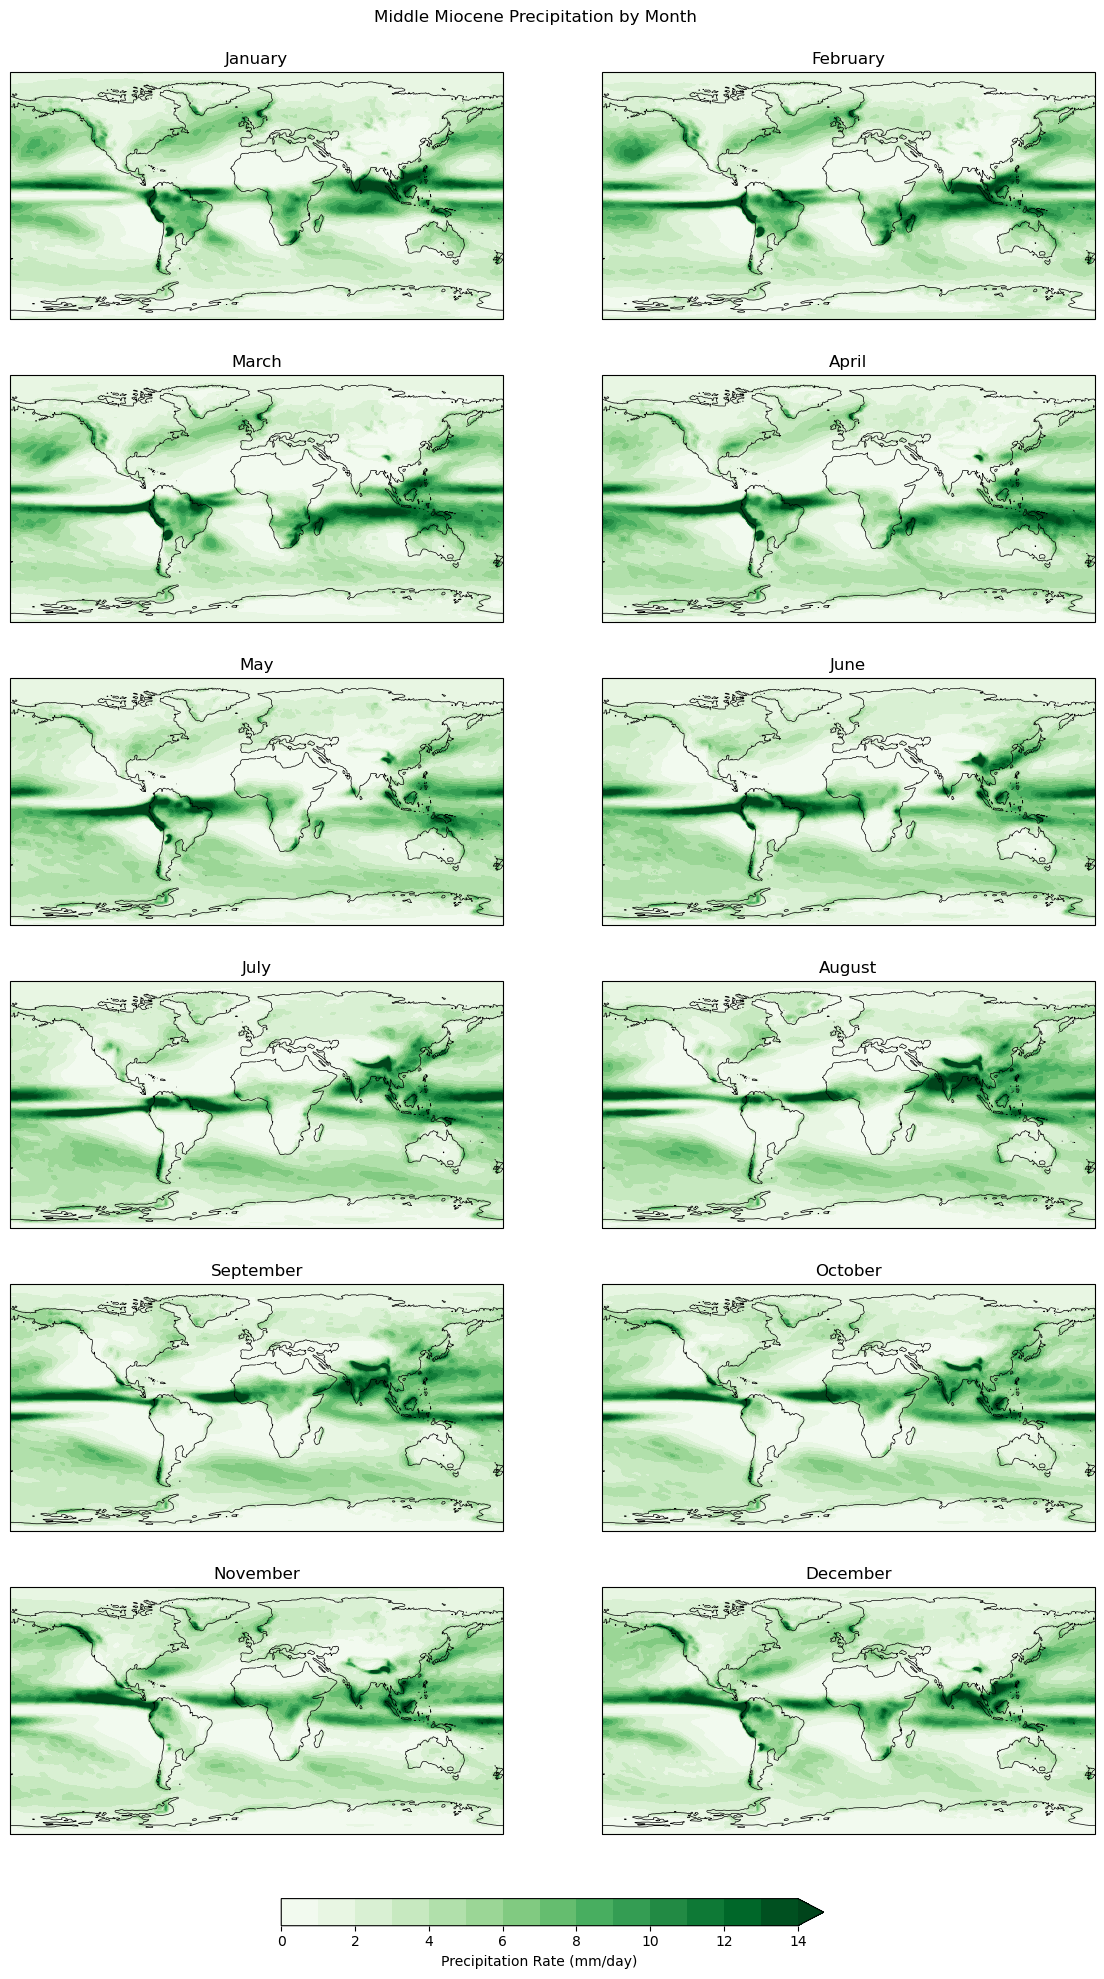

In [4]:
#setting up figure
fig, axs = plt.subplots(nrows=6,ncols=2,subplot_kw={"projection":ccrs.PlateCarree()}, figsize=(14,28))
axs = axs.flatten()

month_names = ["January","February","March","April","May","June","July","August","September","October","November","December"]
clevs = np.linspace(0,14,15)

precip_cyclic = []
for i in range(12):   
    #adding cyclic point
    lat = precip_avgs[i].lat
    precip_cyclic.append([])
    precip_cyclic[i], lons = add_cyclic_point(precip_avgs[i], coord=precip_avgs[i].lon)

    #making the subplots
    plot = axs[i].contourf(lons,lat,precip_cyclic[i],levels=clevs,transform=ccrs.PlateCarree(),cmap="Greens",extend="max")
    axs[i].contour(topo_file.lon, topo_file.lat, topo_file.topo, levels=[0], transform=ccrs.PlateCarree(), colors="k", linewidths=0.5)
    axs[i].set_title(month_names[i])

#adding colorbar and figure title
fig.colorbar(plot, ax=axs, orientation="horizontal", shrink=0.5, pad=0.03, label="Precipitation Rate (mm/day)")
plt.suptitle("Middle Miocene Precipitation by Month", y=0.9)